#  Day 29 — Smart Expense Tracker & Budget Analyzer

Complete notebook workflow: dataset submission → cleaning → automatic categorization → savings → charts → budget analysis → prediction → report export.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPORT_DIR = Path('reports'); CHART_DIR = Path('charts')
REPORT_DIR.mkdir(exist_ok=True); CHART_DIR.mkdir(exist_ok=True)
print(' Libraries loaded')

 Libraries loaded


##  Dataset Submission Block

Use `data/sample_expenses.csv` for the included demo dataset, or replace `DATA_PATH` with your own CSV.

In [2]:
DATA_PATH = Path('data/sample_expenses.csv')
# Example for your own file:
# DATA_PATH = Path(r'C:/Users/YourName/Desktop/expenses.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
print(' Dataset:', DATA_PATH)

 Dataset: data\sample_expenses.csv


In [3]:
df = pd.read_csv(DATA_PATH)
required = {'Date','Description','Amount'}
missing = required - set(df.columns)
if missing: raise ValueError(f'Missing columns: {missing}')

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df['Description'] = df['Description'].astype(str).str.strip()
df = df.dropna(subset=['Date','Amount'])
df = df[df['Amount'] >= 0].copy()
if 'Category' not in df.columns: df['Category'] = ''
print(f' Valid records: {len(df):,}')
display(df.head())

 Valid records: 43


,Date,Description,Amount,Category
0,2026-05-01,Monthly Rent,15000,Rent & Housing
1,2026-05-03,Groceries,3200,NaN
2,2026-05-05,Uber Ride,450,NaN
3,2026-05-07,Electricity Bill,1800,NaN
4,2026-05-09,Amazon Purchase,1800,NaN


##  Automatic Categorization

In [4]:
CATEGORY_RULES = {
'Food & Dining':['food','grocery','groceries','swiggy','zomato','restaurant','cafe','coffee','bakery','dining','meal','lunch','dinner'],
'Transport':['uber','ola','fuel','petrol','diesel','metro','bus','train','cab','transport','parking'],
'Shopping':['amazon','flipkart','myntra','shopping','clothes','fashion','shoes','electronics','mall','purchase'],
'Bills & Utilities':['electricity','water','internet','wifi','mobile','phone','recharge','gas','utility','bill'],
'Entertainment':['movie','netflix','spotify','prime','concert','game','gaming','entertainment'],
'Health':['pharmacy','medicine','hospital','doctor','clinic','health','medical','gym'],
'Education':['course','book','books','udemy','coursera','education','college','tuition','stationery'],
'Travel':['hotel','flight','airbnb','travel','trip','booking','vacation'],
'Rent & Housing':['rent','maintenance','housing','hostel'],
'Personal Care':['salon','spa','cosmetics','beauty','personal care']}

def categorize(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', str(text).lower())
    for category, words in CATEGORY_RULES.items():
        if any(w in text for w in words): return category
    return 'Other'

existing = df['Category'].fillna('').astype(str).str.strip()
detected = df['Description'].map(categorize)
df['Category'] = np.where(existing.eq('') | existing.eq('Other'), detected, existing)
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Day'] = df['Date'].dt.date.astype(str)
df['Weekday'] = df['Date'].dt.day_name()
display(df[['Date','Description','Category','Amount']].head(15))

,Date,Description,Category,Amount
0,2026-05-01,Monthly Rent,Rent & Housing,15000
1,2026-05-03,Groceries,Food & Dining,3200
2,2026-05-05,Uber Ride,Transport,450
3,2026-05-07,Electricity Bill,Bills & Utilities,1800
4,2026-05-09,Amazon Purchase,Shopping,1800
5,2026-05-12,Netflix Subscription,Entertainment,649
6,2026-05-15,Pharmacy,Health,700
7,2026-05-18,Cafe Coffee,Food & Dining,420
8,2026-05-22,Fuel,Transport,2200
9,2026-05-25,Udemy Course,Education,1200


##  Savings & Budget Summary

In [5]:
MONTHLY_INCOME = 50000
total_expense = df['Amount'].sum()
savings = MONTHLY_INCOME - total_expense
savings_rate = savings / MONTHLY_INCOME * 100 if MONTHLY_INCOME else 0

print(f'Total Expenses : ₹{total_expense:,.2f}')
print(f'Savings        : ₹{savings:,.2f}')
print(f'Savings Rate   : {savings_rate:.2f}%')

Total Expenses : ₹116,406.00
Savings        : ₹-66,406.00
Savings Rate   : -132.81%


##  Chart 1 — Monthly Spending Trend

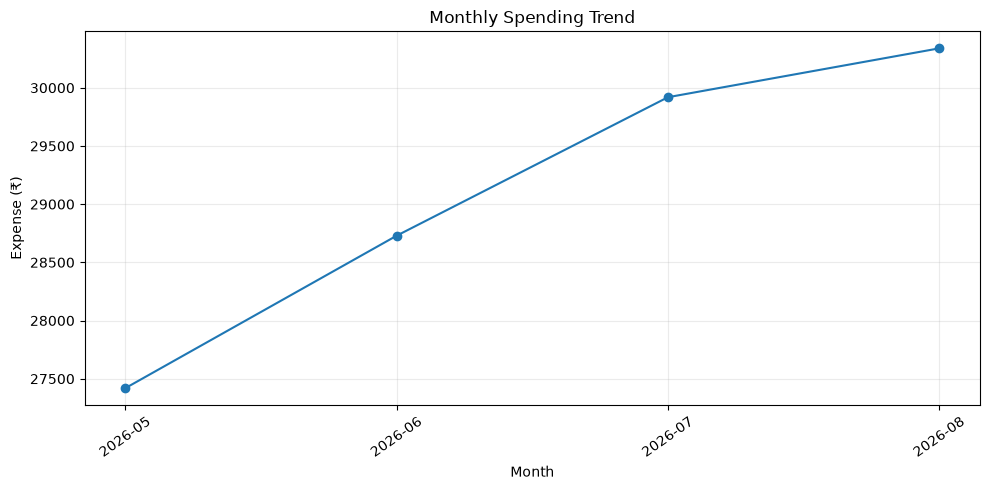

In [6]:
monthly = df.groupby('Month', as_index=False)['Amount'].sum()
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly['Month'], monthly['Amount'], marker='o')
ax.set(title='Monthly Spending Trend', xlabel='Month', ylabel='Expense (₹)')
ax.grid(alpha=.25); plt.xticks(rotation=35); plt.tight_layout()
plt.savefig(CHART_DIR/'01_monthly_spending_trend.png', dpi=180, bbox_inches='tight')
plt.show()

##  Chart 2 — Category Distribution

,Category,Amount,Share %
5,Rent & Housing,60000,51.543735
3,Food & Dining,20940,17.988763
7,Transport,11100,9.535591
6,Shopping,8500,7.302029
0,Bills & Utilities,7900,6.786592
4,Health,3200,2.748999
1,Education,2700,2.319468
2,Entertainment,2066,1.774823


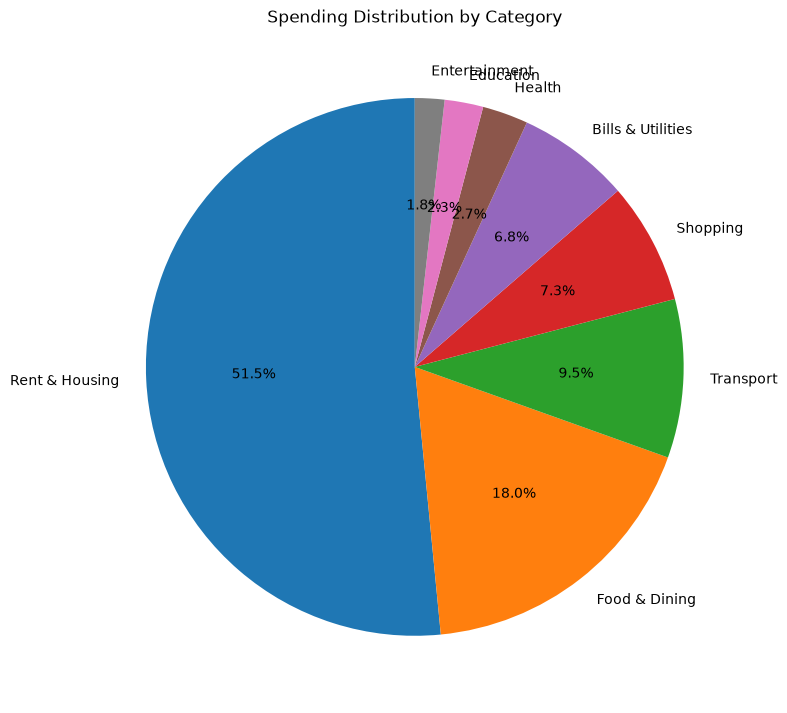

In [7]:
category = df.groupby('Category', as_index=False)['Amount'].sum().sort_values('Amount', ascending=False)
category['Share %'] = category['Amount'] / category['Amount'].sum() * 100
display(category)
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(category['Amount'], labels=category['Category'], autopct='%1.1f%%', startangle=90)
ax.set_title('Spending Distribution by Category')
plt.tight_layout(); plt.savefig(CHART_DIR/'03_category_distribution.png', dpi=180, bbox_inches='tight'); plt.show()

##  Chart 3 — Daily Spending

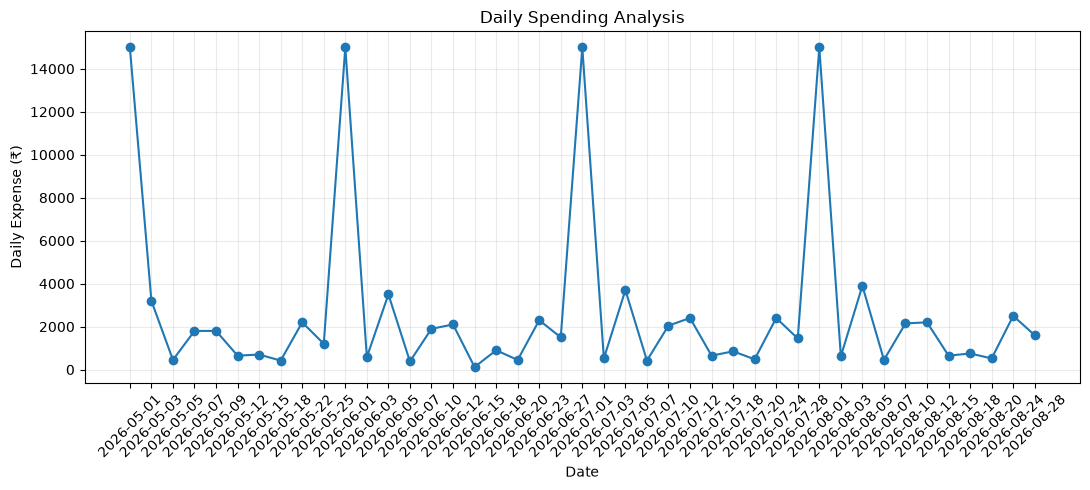

In [8]:
daily = df.groupby('Day', as_index=False)['Amount'].sum()
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(daily['Day'], daily['Amount'], marker='o')
ax.set(title='Daily Spending Analysis', xlabel='Date', ylabel='Daily Expense (₹)')
ax.grid(alpha=.25); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(CHART_DIR/'04_daily_spending.png', dpi=180, bbox_inches='tight'); plt.show()

##  Budget vs Actual

In [9]:
budgets = {'Food & Dining':10000,'Transport':5000,'Shopping':7000,'Bills & Utilities':7000,'Entertainment':4000,'Health':4000,'Education':3000,'Travel':5000,'Rent & Housing':15000,'Personal Care':2500,'Other':3000}
budget = pd.DataFrame({'Category':list(budgets), 'Budget':list(budgets.values())})
budget = budget.merge(category[['Category','Amount']], on='Category', how='left').fillna({'Amount':0})
budget = budget.rename(columns={'Amount':'Actual'})
budget['Variance'] = budget['Budget'] - budget['Actual']
budget['Used %'] = np.where(budget['Budget']>0, budget['Actual']/budget['Budget']*100, 0)
budget['Status'] = np.where(budget['Variance']>=0,'Within Budget','Over Budget')
display(budget)

,Category,Budget,Actual,Variance,Used %,Status
0,Food & Dining,10000,20940.0,-10940.0,209.400000,Over Budget
1,Transport,5000,11100.0,-6100.0,222.000000,Over Budget
2,Shopping,7000,8500.0,-1500.0,121.428571,Over Budget
3,Bills & Utilities,7000,7900.0,-900.0,112.857143,Over Budget
4,Entertainment,4000,2066.0,1934.0,51.650000,Within Budget
5,Health,4000,3200.0,800.0,80.000000,Within Budget
6,Education,3000,2700.0,300.0,90.000000,Within Budget
7,Travel,5000,0.0,5000.0,0.000000,Within Budget
8,Rent & Housing,15000,60000.0,-45000.0,400.000000,Over Budget
9,Personal Care,2500,0.0,2500.0,0.000000,Within Budget


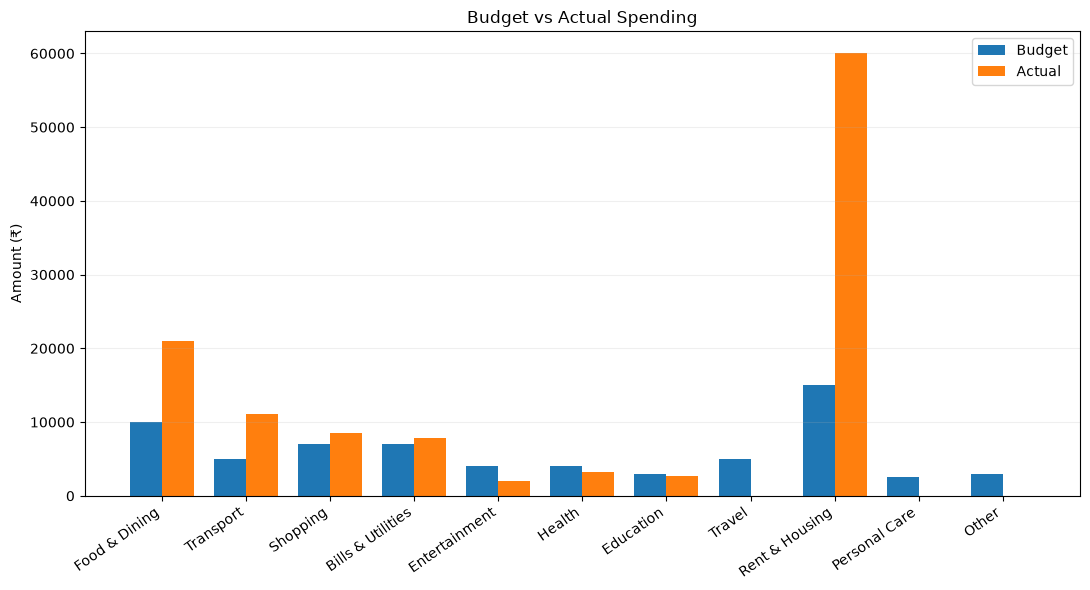

In [10]:
b = budget[(budget['Budget']>0)|(budget['Actual']>0)]
fig, ax = plt.subplots(figsize=(11,6)); x=np.arange(len(b)); w=.38
ax.bar(x-w/2,b['Budget'],w,label='Budget'); ax.bar(x+w/2,b['Actual'],w,label='Actual')
ax.set(title='Budget vs Actual Spending', ylabel='Amount (₹)')
ax.set_xticks(x); ax.set_xticklabels(b['Category'],rotation=35,ha='right')
ax.legend(); ax.grid(axis='y',alpha=.2); plt.tight_layout()
plt.savefig(CHART_DIR/'05_budget_vs_actual.png',dpi=180,bbox_inches='tight'); plt.show()

##  Bonus — Next-Month Expense Prediction

In [11]:
if len(monthly) >= 3:
    y = monthly.tail(3)['Amount'].to_numpy(float)
    x = np.arange(3)
    slope, intercept = np.polyfit(x,y,1)
    prediction = max(0, slope*3 + intercept)
    print(f'Estimated next-month expense: ₹{prediction:,.2f}')
else:
    prediction = None
    print('Need at least 3 months of data.')
print(' Educational estimate, not financial advice.')

Estimated next-month expense: ₹31,272.33
 Educational estimate, not financial advice.


##  Export Final Reports

In [12]:
df.to_csv(REPORT_DIR/'cleaned_expenses.csv',index=False)
monthly.to_csv(REPORT_DIR/'monthly_expense_summary.csv',index=False)
category.to_csv(REPORT_DIR/'category_expense_summary.csv',index=False)
daily.to_csv(REPORT_DIR/'daily_expense_summary.csv',index=False)
budget.to_csv(REPORT_DIR/'budget_analysis.csv',index=False)
print(' Reports exported to', REPORT_DIR.resolve())
print(' Charts exported to', CHART_DIR.resolve())

✅ Reports exported to C:\Users\itssh\OneDrive\Documents\GitHub\rftinternship\RFTinternship\Day 29\reports
 Charts exported to C:\Users\itssh\OneDrive\Documents\GitHub\rftinternship\RFTinternship\Day 29\charts
